# Chapter 4 — Implementing a GPT model from scratch to generate text

This notebook assembles the components developed in earlier chapters into a GPT-style language model. The implementation begins with
a validated architecture configuration and a shape-preserving dummy model before replacing each placeholder with a real Transformer
component.

## Learning goals

- represent model hyperparameters with a typed, validated configuration;
- trace token IDs through embeddings, Transformer blocks, normalization, and logits;
- preserve `(batch, tokens, embedding)` shapes through the Transformer blocks; and
- produce one vocabulary-logit vector per input token.

In [1]:
#| default_exp model

In [2]:
#| export
from typing import Self

import torch
from pydantic import BaseModel, ConfigDict, Field, model_validator
from torch import nn

from build_llms_from_scratch_companion.attention import MultiHeadAttention

## 4.1 Defining a typed and validated GPT configuration

A plain dictionary accepts misspelled keys, missing values, invalid ranges, and incompatible dimensions until much later in model
construction. `GPTConfig` replaces string-based access such as `cfg["emb_dim"]` with typed attribute access such as `cfg.emb_dim`.

Pydantic validates values when the object is created. Positive dimensions, a dropout rate in `[0, 1)`, and divisibility of `emb_dim`
by `num_heads` become explicit architecture contracts. Freezing the model prevents accidental mutation after layers are initialized.

In [3]:
#| export
class GPTConfig(BaseModel):
    """Validated architecture settings for a GPT-style language model."""

    # Configuration objects behave like immutable architecture specifications.
    model_config = ConfigDict(frozen=True)

    vocab_size: int = Field(gt=0, description="Number of tokenizer vocabulary entries")
    context_length: int = Field(gt=0, description="Maximum supported token sequence length")
    emb_dim: int = Field(
        gt=0, description="Token embedding and model dimension, also called d_model"
    )
    num_heads: int = Field(gt=0, description="Number of parallel attention heads")
    num_layers: int = Field(gt=0, description="Number of Transformer blocks")
    dropout_rate: float = Field(ge=0.0, lt=1.0, description="Dropout probability")
    qkv_bias: bool = Field(description="Whether QKV projections include bias terms")

    @model_validator(mode="after")
    def validate_attention_dimensions(self) -> Self:
        """Require every attention head to receive an equal feature width."""
        if self.emb_dim % self.num_heads != 0:
            raise ValueError("emb_dim must be divisible by num_heads")
        return self

    @property
    def head_dim(self) -> int:
        """Return the query, key, and value width assigned to one head."""
        return self.emb_dim // self.num_heads


# GPT-2 small / 124M uses a model dimension of 768 and 12 attention heads.
GPT_CONFIG_124M = GPTConfig(
    vocab_size=50257,
    context_length=1024,
    emb_dim=768,
    num_heads=12,
    num_layers=12,
    dropout_rate=0.1,
    qkv_bias=False,
)

### GPT-2 small configuration

`GPT_CONFIG_124M` describes the smallest GPT-2 architecture: a 50,257-token vocabulary, context length 1,024, embedding dimension 768,
12 heads, and 12 Transformer blocks. Its derived `head_dim` is `768 / 12 = 64`.

Use `GPT_CONFIG_124M.model_dump()` only when an external API specifically requires a dictionary; model code should prefer typed
attributes.

## 4.2 Creating shape-preserving placeholders

Before implementing full Transformer blocks and layer normalization, identity modules let us assemble and test the outer GPT data
flow. They expose the same typed interfaces as the eventual components while returning inputs unchanged.

In [4]:
class DummyTransformerBlock(nn.Module):
    """Placeholder Transformer block that preserves its input unchanged."""

    def __init__(self, cfg: GPTConfig) -> None:
        """Accept the final block interface without creating operations yet."""
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return a tensor with the same values and shape as the input."""
        return x


class DummyLayerNorm(nn.Module):
    """Placeholder final normalization that acts as an identity function."""

    def __init__(self, normalized_shape: int, eps: float = 1e-5) -> None:
        """Accept the final normalization interface without parameters yet."""
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return a tensor with the same values and shape as the input."""
        return x

## 4.3 Assembling the dummy GPT model

The model maps token IDs through these stages:

```text
token IDs                     (B, T)
token embeddings              (B, T, emb_dim)
positional embeddings         (T, emb_dim)
combined token representations (B, T, emb_dim)
Transformer block stack       (B, T, emb_dim)
final normalization           (B, T, emb_dim)
vocabulary logits             (B, T, vocab_size)
```

Positional embeddings broadcast across the batch. The output head changes only the final feature dimension, producing one vector of
next-token scores for every input position. During training, all positions are predicted in parallel, which makes the
computation efficient; autoregressive generation typically uses only the final position.

In [5]:
class DummyGPTModel(nn.Module):
    """Trace GPT tensor shapes while Transformer internals remain placeholders."""

    def __init__(self, cfg: GPTConfig) -> None:
        """Create embeddings, placeholder blocks, normalization, and output head."""
        super().__init__()
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.emb_dim)
        self.pos_emb = nn.Embedding(cfg.context_length, cfg.emb_dim)
        self.drop_emb = nn.Dropout(cfg.dropout_rate)
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg.num_layers)]
        )
        self.final_norm = DummyLayerNorm(cfg.emb_dim)
        self.out_head = nn.Linear(cfg.emb_dim, cfg.vocab_size, bias=False)

    def forward(self, in_idx: torch.Tensor) -> torch.Tensor:
        """Map token IDs `(B, T)` to vocabulary logits `(B, T, vocab_size)`."""
        # in_idx: (batch_size, num_tokens)
        _, num_tokens = in_idx.shape

        # tok_embeds: (batch_size, num_tokens, emb_dim)
        tok_embeds = self.tok_emb(in_idx)
        # pos_embeds: (num_tokens, emb_dim), broadcast across the batch dimension
        pos_embeds = self.pos_emb(torch.arange(num_tokens, device=in_idx.device))

        # x: (batch_size, num_tokens, emb_dim)
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        # Placeholder blocks and normalization preserve x's shape.
        x = self.trf_blocks(x)
        x = self.final_norm(x)

        # One next-token prediction per position, computed in parallel.
        # logits: (batch_size, num_tokens, vocab_size)
        logits = self.out_head(x)
        return logits

## 4.4 Running text through the dummy GPT model

Before testing the model, encode two text samples with the GPT-2 tokenizer. `torch.stack` requires equal-length token sequences and
adds the batch dimension, producing integer token IDs with shape `(batch_size, num_tokens) = (2, 4)`.

In [6]:
import tiktoken

# Encode two equal-length text samples so they can be stacked into one batch.
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

# Each encoded sample has shape (num_tokens,).
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
# batch: (batch_size=2, num_tokens=4)
batch = torch.stack(batch, dim=0)
batch

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

### Producing vocabulary logits

The dummy model transforms `(2, 4)` token IDs into logits with shape `(2, 4, 50257)`. It produces one vocabulary-score vector for
each token position, so all next-token training predictions are computed in parallel. Autoregressive generation normally uses only
the final position's logits.

In [7]:
# Reproduce the dummy model's random initialization and dropout pattern.
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
# batch: (2, 4) -> logits: (2, 4, 50257)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.5 Understanding layer normalization

Layer normalization standardizes the feature values belonging to each individual example or token. This small `(2, 6)` activation
matrix makes the calculation visible before it is generalized to three-dimensional GPT tensors.

In [8]:
# Create a small feature matrix for a manual normalization example.
torch.manual_seed(123)
# batch_example: (batch_size=2, input_features=5)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
# out: (batch_size=2, output_features=6)
out = layer(batch_example)
out

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

### Computing per-row statistics

`dim=-1` selects the feature dimension, so each row receives its own mean and variance. `keepdim=True` retains a singleton feature
dimension, changing `(2, 6)` into `(2, 1)` and enabling broadcasting during normalization.

In [9]:
# Reduce across features independently for each batch item.
# mean and var: (batch_size=2, 1); keepdim enables feature-wise broadcasting.
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:")
print(mean)
print("Variance:")
print(var)

Mean:
tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


### Normalizing the activations

Subtracting each row's mean centers its values around zero. Dividing by its standard deviation scales the row to unit variance. The
output shape remains `(2, 6)` because the `(2, 1)` statistics broadcast across all six features.

In [10]:
# Broadcast each row's statistics across its six feature values.
# out_norm: (batch_size=2, output_features=6)
out_norm = (out - mean) / torch.sqrt(var)
# Recompute row statistics to verify zero mean and unit variance.
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:")
print(out_norm)
print("Mean:")
print(mean)
print("Variance:")
print(var)

Normalized layer outputs:
tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


### Displaying near-zero values clearly

Floating-point means may be extremely close to zero without being exactly zero. Disabling scientific notation changes only their
printed representation; it does not modify the tensors.

In [11]:
# Disable scientific notation to make near-zero means easier to read.
torch.set_printoptions(sci_mode=False)
print("Mean:")
print(mean)
print("Variance:")
print(var)

Mean:
tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance:
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## 4.6 Implementing a reusable `LayerNorm`

GPT applies layer normalization independently to the `emb_dim` features of every token. For input shape
`(batch_size, num_tokens, emb_dim)`, the mean and variance have shape `(batch_size, num_tokens, 1)` and broadcast back across features.

The implementation uses `unbiased=False`, matching the population-variance calculation used by layer normalization. `eps` prevents
division by zero, while learnable `scale` and `shift` parameters let training adjust the normalized representation.

In [12]:
#| export
class LayerNorm(nn.Module):
    """Normalize each token across its embedding features."""

    def __init__(self, emb_dim: int) -> None:
        """Create learnable scale and shift vectors of width `emb_dim`."""
        super().__init__()
        self.eps = 1e-5
        # scale and shift: (emb_dim,), broadcast across batch and tokens
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Normalize `(batch_size, num_tokens, emb_dim)` without changing shape."""
        # mean and var: (batch_size, num_tokens, 1)
        mean = x.mean(dim=-1, keepdim=True)
        # LayerNorm uses population variance rather than the unbiased estimate.
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        # norm_x: (batch_size, num_tokens, emb_dim)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        # Learned affine parameters broadcast across batch and token dimensions.
        return self.scale * norm_x + self.shift

### Verifying the `LayerNorm` module

Apply the reusable layer to the same `(2, 6)` activations and inspect each row's statistics. The normalized means should be close to
zero and the population variances close to one. They may be slightly below one because `eps` is included in the denominator for
numerical stability.

In [13]:
# Apply LayerNorm independently to each row of the (2, 6) activation matrix.
ln = LayerNorm(emb_dim=6)
# out_ln: (batch_size=2, emb_dim=6)
out_ln = ln(out)
# Verification statistics: (batch_size=2, 1)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:")
print(mean)
print("Variance:")
print(var)

Mean:
tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Variance:
tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)


## 4.7 Implementing the GELU activation

GPT-2 uses the **Gaussian Error Linear Unit (GELU)** instead of ReLU. The approximation implemented in the book is:

```text
GELU(x) ≈ 0.5 × x × [1 + tanh(sqrt(2 / pi) × (x + 0.044715 × x³))]
```

GELU is smooth and scales inputs according to their magnitude rather than applying ReLU's hard cutoff at zero. It has no trainable
parameters and operates element-wise, so its output shape always matches its input shape.

In [14]:
#| export
class GELU(nn.Module):
    """Apply the smooth Gaussian Error Linear Unit approximation."""

    def __init__(self) -> None:
        """Initialize a parameter-free activation module."""
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply GELU element-wise without changing the input shape."""
        # The tanh approximation used by GPT preserves every tensor dimension.
        return (
            0.5
            * x
            * (
                1
                + torch.tanh(
                    torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
                )
            )
        )

### Comparing GELU with ReLU

Plot both functions over the same interval. ReLU returns zero for every negative input and is linear for positive inputs. GELU keeps
small negative values and transitions smoothly around zero, giving the network a differentiable gating behavior.

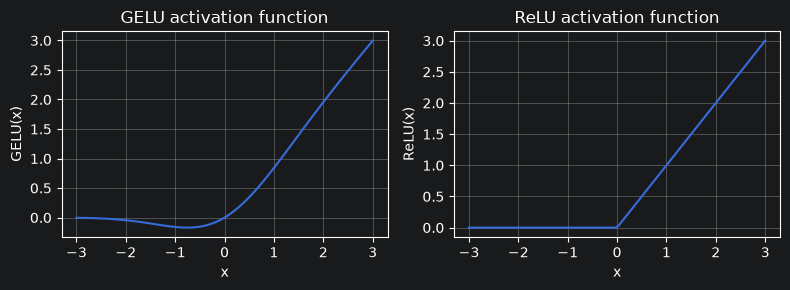

In [15]:
import matplotlib.pyplot as plt

# Compare the book's GELU implementation with PyTorch's ReLU.
gelu, relu = GELU(), nn.ReLU()
# x, y_gelu, y_relu: (num_points=100,)
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

# Draw one subplot per activation function using the same input range.
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(
    zip([y_gelu, y_relu], ["GELU", "ReLU"], strict=False),
    1,
):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

## 4.8 Implementing the position-wise feed-forward network

After attention mixes information across token positions, GPT applies the same feed-forward network independently to every token.
The network changes feature width internally but preserves the model's external shape:

```text
input                 (batch_size, num_tokens, emb_dim)
first linear layer    (batch_size, num_tokens, 4 * emb_dim)
GELU                  (batch_size, num_tokens, 4 * emb_dim)
second linear layer   (batch_size, num_tokens, emb_dim)
```

The fourfold expansion gives each token a larger feature space for nonlinear processing. Projecting back to `emb_dim` restores the
shape needed by the Transformer block's residual connection. The layer now accepts the validated `GPTConfig` object and uses typed
attribute access rather than dictionary keys.

In [16]:
#| export
class FeedForward(nn.Module):
    """Apply GPT's position-wise two-layer feed-forward network."""

    def __init__(self, cfg: GPTConfig) -> None:
        """Expand token features fourfold, apply GELU, and project them back."""
        super().__init__()
        self.layers = nn.Sequential(
            # (batch_size, num_tokens, emb_dim)
            # -> (batch_size, num_tokens, 4 * emb_dim)
            nn.Linear(cfg.emb_dim, 4 * cfg.emb_dim),
            # GELU preserves (batch_size, num_tokens, 4 * emb_dim).
            GELU(),
            # -> (batch_size, num_tokens, emb_dim)
            nn.Linear(4 * cfg.emb_dim, cfg.emb_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Transform each token independently without changing tensor shape."""
        # x and output: (batch_size, num_tokens, emb_dim)
        return self.layers(x)

### Verifying the feed-forward shape contract

Instantiate `FeedForward` with `GPT_CONFIG_124M`, then pass a small `(2, 3, 768)` tensor through it. The internal expansion is hidden
inside the module; the observed output remains `(batch_size, num_tokens, emb_dim)`.

In [17]:
# FeedForward reads emb_dim=768 from the validated GPT configuration.
ffn = FeedForward(GPT_CONFIG_124M)
# x and out: (batch_size=2, num_tokens=3, emb_dim=768)
x = torch.rand(2, 3, GPT_CONFIG_124M.emb_dim)
out = ffn(x)
out.shape

torch.Size([2, 3, 768])

## 4.9 Understanding shortcut connections

A shortcut connection adds a layer's input directly to its transformed output:

```text
output = x + layer(x)
```

The addition requires identical tensor shapes. Shortcuts give gradients a direct path through deep networks, helping earlier layers
receive a stronger training signal. GPT Transformer blocks use this pattern around both attention and feed-forward sublayers.

### A network for comparing gradient flow

`ExampleDeepNeuralNetwork` builds five linear-GELU stages. When `use_shortcut=True`, a layer output is added to its input only if their
feature widths match. The final `3 -> 1` layer cannot use a shortcut because addition would be undefined for different shapes.

In [18]:
class ExampleDeepNeuralNetwork(nn.Module):
    """Demonstrate gradient flow with optional shape-preserving shortcuts."""

    def __init__(self, layer_sizes: list[int], use_shortcut: bool) -> None:
        """Create five linear-GELU layers with the requested feature widths."""
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList(
            [
                nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
                nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU()),
            ]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply each layer and add its input when shortcut shapes match."""
        for layer in self.layers:
            layer_output = layer(x)
            # Addition is valid only when both tensors have identical shapes.
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

### Preparing the no-shortcut baseline

The width sequence `[3, 3, 3, 3, 3, 1]` creates a deep stack whose early layers repeatedly transform three features. Begin with
shortcuts disabled to observe how gradient magnitudes change across a plain deep network.

In [19]:
# The first four layers preserve width 3; the final layer maps 3 -> 1.
layer_sizes = [3, 3, 3, 3, 3, 1]
# sample_input: (batch_size=1, input_features=3)
sample_input = torch.tensor([[1.0, 0.0, -1.0]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes,
    use_shortcut=False,
)

### Inspecting gradients after backpropagation

The helper computes a scalar mean-squared-error loss, calls `backward()`, and reports the mean absolute gradient for every weight
matrix. Smaller values indicate a weaker update signal reaching that layer.

The helper assumes gradients are initially clear, as they are for each newly constructed model in this comparison.

In [20]:
def print_gradients(model: nn.Module, x: torch.Tensor) -> None:
    """Backpropagate a scalar MSE loss and print mean weight gradients."""
    # output and target: (batch_size=1, output_features=1)
    output = model(x)
    target = torch.tensor([[0.0]])

    loss_function = nn.MSELoss()
    loss = loss_function(output, target)
    loss.backward()

    # Earlier layers often receive smaller gradients in a deep plain network.
    for name, parameter in model.named_parameters():
        if "weight" in name and parameter.grad is not None:
            gradient_mean = parameter.grad.abs().mean().item()
            print(f"{name} has gradient mean of {gradient_mean}")

### Gradient flow without shortcuts

The printed baseline shows that early layers receive very small gradients compared with layers near the output. The next comparison
can enable shortcuts while keeping the architecture and random initialization controlled.

In [21]:
# Establish the no-shortcut baseline for the gradient comparison.
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173590746708214
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152042235247791
layers.3.0.weight has gradient mean of 0.0013988739810883999
layers.4.0.weight has gradient mean of 0.00504964729771018


### Gradient flow with shortcuts

Recreate the network with the same random seed so its initial weights match the baseline, then enable shape-compatible shortcuts.
Comparing the printed gradients isolates the effect of the alternate gradient paths rather than differences in initialization.

In [22]:
# Recreate the same initialization, this time enabling shortcuts.
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes,
    use_shortcut=True,
)
# Compare mean gradient magnitudes with the no-shortcut baseline.
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694102346897125
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


## 4.10 Assembling a Transformer block

A GPT Transformer block contains two shape-preserving sublayers:

1. causal multi-head attention mixes information across token positions;
2. the feed-forward network transforms each token's features independently.

This implementation uses **pre-normalization**: each sublayer receives normalized input, then dropout is applied before adding the
unchanged shortcut. Every public boundary preserves `(batch_size, num_tokens, emb_dim)`, so both additions are shape-safe.

```text
input x                       (batch_size, num_tokens, emb_dim)
LayerNorm -> attention        (batch_size, num_tokens, emb_dim)
attention shortcut addition   (batch_size, num_tokens, emb_dim)
LayerNorm -> feed-forward     (batch_size, num_tokens, emb_dim)
feed-forward shortcut         (batch_size, num_tokens, emb_dim)
```

The block accepts `GPTConfig` directly. It sets `d_in == d_out == cfg.emb_dim`, matching the paper's model-dimension contract and the
requirements of the shortcut connections. The `#| export` directive makes this notebook the source of truth for the reusable class.

In [23]:
#| export
class TransformerBlock(nn.Module):
    """Apply one pre-normalization GPT Transformer block."""

    def __init__(self, cfg: GPTConfig) -> None:
        """Initialize attention, feed-forward, normalization, and dropout layers."""
        super().__init__()
        # d_in == d_out == emb_dim preserves the shortcut-addition contract.
        self.att = MultiHeadAttention(
            d_in=cfg.emb_dim,
            d_out=cfg.emb_dim,
            context_length=cfg.context_length,
            num_heads=cfg.num_heads,
            dropout=cfg.dropout_rate,
            qkv_bias=cfg.qkv_bias,
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg.emb_dim)
        self.norm2 = LayerNorm(cfg.emb_dim)
        self.drop_shortcut = nn.Dropout(cfg.dropout_rate)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Preserve `(batch_size, num_tokens, emb_dim)` through both sublayers."""
        # x and shortcut: (batch_size, num_tokens, emb_dim)
        shortcut = x
        # norm1 preserves: (batch_size, num_tokens, emb_dim)
        x = self.norm1(x)
        # att preserves shape because d_in == d_out == emb_dim.
        x = self.att(x)
        # Dropout changes values during training, never tensor shape.
        x = self.drop_shortcut(x)
        # Both operands: (batch_size, num_tokens, emb_dim)
        x = x + shortcut

        # Start the feed-forward shortcut from the attention sublayer output.
        # x and shortcut: (batch_size, num_tokens, emb_dim)
        shortcut = x
        # norm2 preserves: (batch_size, num_tokens, emb_dim)
        x = self.norm2(x)
        # ff expands internally to 4 * emb_dim, then returns emb_dim.
        x = self.ff(x)
        x = self.drop_shortcut(x)
        # Final output: (batch_size, num_tokens, emb_dim)
        x = x + shortcut
        return x

### Verifying the Transformer block's shape contract

A Transformer block must return the same shape it receives because GPT stacks many blocks and adds shortcuts inside each one. Pass a
small activation tensor through one block and verify that attention, feed-forward processing, dropout, and both shortcut additions
preserve `(batch_size, num_tokens, emb_dim)`.

In [24]:
# Use a fixed seed so dropout and parameter initialization are reproducible.
torch.manual_seed(123)
# x: (batch_size=2, num_tokens=4, emb_dim=768)
x = torch.rand(2, 4, GPT_CONFIG_124M.emb_dim)
block = TransformerBlock(GPT_CONFIG_124M)
# output: (batch_size=2, num_tokens=4, emb_dim=768)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


## 4.11 Assembling the complete GPT model

`GPTModel` replaces the earlier placeholder architecture with functional Transformer blocks. Its data flow is:

```text
token IDs                 (batch_size, num_tokens)
token embeddings          (batch_size, num_tokens, emb_dim)
position embeddings       (num_tokens, emb_dim)
combined embeddings       (batch_size, num_tokens, emb_dim)
Transformer block stack   (batch_size, num_tokens, emb_dim)
final LayerNorm           (batch_size, num_tokens, emb_dim)
vocabulary logits         (batch_size, num_tokens, vocab_size)
```

Position embeddings omit the batch dimension because the same position indices apply to every sequence; PyTorch broadcasts them
across the token-embedding batch during addition. The output head then makes one parallel next-token prediction at every position.
Generation will select the logits at the final position to choose the next token.

The model accepts `GPTConfig`, preserving one validated source for vocabulary size, maximum `context_length`, model dimension, layer
count, and dropout rate. The `#| export` directive includes `GPTModel` in the generated reusable module.

In [25]:
#| export
class GPTModel(nn.Module):
    """Assemble the token embeddings, Transformer blocks, and output head."""

    def __init__(self, cfg: GPTConfig) -> None:
        """Initialize a GPT model from a validated architecture configuration."""
        super().__init__()
        # Token and position lookups both produce vectors of width emb_dim.
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.emb_dim)
        self.pos_emb = nn.Embedding(cfg.context_length, cfg.emb_dim)
        self.drop_emb = nn.Dropout(cfg.dropout_rate)

        # Every block preserves (batch_size, num_tokens, emb_dim).
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg.num_layers)]
        )

        self.final_norm = LayerNorm(cfg.emb_dim)
        # Map each token representation to one score per vocabulary entry.
        self.out_head = nn.Linear(cfg.emb_dim, cfg.vocab_size, bias=False)

    def forward(self, in_idx: torch.Tensor) -> torch.Tensor:
        """Map token IDs to next-token logits at every sequence position."""
        # in_idx: (batch_size, num_tokens)
        num_tokens = in_idx.shape[1]

        # tok_embeds: (batch_size, num_tokens, emb_dim)
        tok_embeds = self.tok_emb(in_idx)
        # positions: (num_tokens,)
        positions = torch.arange(num_tokens, device=in_idx.device)
        # pos_embeds: (num_tokens, emb_dim), broadcast across the batch
        pos_embeds = self.pos_emb(positions)

        # x: (batch_size, num_tokens, emb_dim)
        x = tok_embeds + pos_embeds
        # Embedding dropout preserves tensor shape.
        x = self.drop_emb(x)
        # Every Transformer block preserves the model dimension.
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        # logits: (batch_size, num_tokens, vocab_size)
        logits = self.out_head(x)
        return logits

## 4.12 Running the complete GPT model

Pass the two tokenized sequences from the earlier example through GPT-2 small. The model returns a vocabulary-sized score vector for
every token position; it does not choose token IDs yet.

The resulting `(2, 4, 50_257)` tensor therefore contains eight parallel next-token predictions. During autoregressive generation, only
the final position from each sequence is used to select its immediate next token.

In [26]:
# Fix initialization and dropout randomness for reproducible logits.
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

# batch: (batch_size=2, num_tokens=4)
# out: (batch_size=2, num_tokens=4, vocab_size=50_257)
out = model(batch)
print("Input batch:")
print(batch)
print("Output shape:", out.shape)
print(out)

Input batch:
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


### Counting trainable parameters

Each `nn.Parameter` is a tensor, and `numel()` returns its number of scalar entries. Summing those counts across the model includes
embedding tables, attention projections, feed-forward layers, normalization parameters, and the output head.

In [27]:
# numel() counts every scalar in each trainable parameter tensor.
total_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


## 4.13 Understanding weight tying

The untied implementation contains two separate matrices with the same shape:

```text
token embedding weight   (vocab_size, emb_dim)
output-head weight        (vocab_size, emb_dim)
```

GPT-2 **ties** these weights: the output projection reuses the token-embedding matrix instead of learning a second copy. The current
`GPTModel` does not yet perform that assignment, so subtracting the output-head parameter count below calculates what the total
*would be* under weight tying; it does not alter the model.

In [28]:
# out_head.weight: (vocab_size=50_257, emb_dim=768)
out_head_params = sum(
    parameter.numel() for parameter in model.out_head.parameters()
)
# In a tied model, the output head reuses the token-embedding matrix.
total_params_gpt2 = total_params - out_head_params
print(
    "Number of trainable parameters considering weight tying: "
    f"{total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


### Interpreting the tied parameter count

Removing the duplicate output matrix reduces the conceptual count from roughly 163 million to roughly 124 million parameters,
matching the named size of GPT-2 small. Parameter-count labels are rounded model-family names rather than exact scalar totals.

## Exercise 4.1 — Comparing attention and feed-forward parameters

Calculate the trainable parameters in one attention module and one feed-forward module. Use `numel()` because a parameter tensor's
`len()` reports only its first dimension rather than the total number of scalar parameters.

Both modules are repeated with the same architecture in every Transformer block, so inspecting the first block gives the per-module
comparison without multiplying each result by `num_layers`.

In [29]:
# Compare one representative block; every configured block has the same size.
first_block = model.trf_blocks[0]
num_weights_attention = sum(
    parameter.numel() for parameter in first_block.att.parameters()
)
num_weights_ff = sum(
    parameter.numel() for parameter in first_block.ff.parameters()
)

num_weights_attention, num_weights_ff

(2360064, 4722432)

## 4.14 Estimating parameter memory

A parameter count measures scalar values, not bytes. Under the model's default `float32` dtype, each parameter occupies four bytes,
so multiplying the untied parameter count by four estimates the storage required by parameter tensors alone.

This estimate excludes temporary activations, gradients, optimizer state, and framework overhead. Training therefore needs substantially
more memory than the raw model-size figure, while lower-precision dtypes can reduce bytes per parameter.

In [30]:
# A float32 parameter occupies 4 bytes; both totals are scalar values.
total_size_bytes = total_params * 4
# Convert bytes to binary megabytes (MiB), conventionally displayed here as MB.
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


## Exercise 4.2 — Initializing larger GPT-2 models

The same `GPTModel` implementation can represent larger GPT-2 variants by changing only `GPTConfig`:

| Variant | `emb_dim` | `num_layers` | `num_heads` |
|---|---:|---:|---:|
| GPT-2 small | 768 | 12 | 12 |
| GPT-2 medium | 1,024 | 24 | 16 |
| GPT-2 large | 1,280 | 36 | 20 |
| GPT-2 XL | 1,600 | 48 | 25 |

Initialize the medium, large, and XL variants without modifying `GPTModel`. As a bonus, calculate each model's total number of scalar
parameters. The Pydantic configuration validates that every `emb_dim` is divisible by `num_heads`, ensuring an integer `head_dim`.

The code below begins with GPT-2 medium. Its public input and output shapes still depend only on `batch_size`, `num_tokens`, and
`vocab_size`; the larger `emb_dim` changes the model's internal representation width.

### Initializing GPT-2 medium

Start by increasing the model dimension, head count, and block count to the medium configuration. Although internal activations widen
from 768 to 1,024 features, the same token batch still produces `(2, 4, 50_257)` logits because its batch size, current token count,
and vocabulary size have not changed.

In [32]:
# Fix initialization and dropout randomness for reproducible logits.
torch.manual_seed(123)
# GPT-2 medium uses emb_dim=1_024 split evenly across 16 heads.
bigger_model_config = GPTConfig(
    vocab_size=50257,
    context_length=1024,
    emb_dim=1024,
    num_heads=16,
    num_layers=24,
    dropout_rate=0.1,
    qkv_bias=False,
)
exo_4_2_model = GPTModel(bigger_model_config)

# batch: (batch_size=2, num_tokens=4)
# Internal block activations: (batch_size=2, num_tokens=4, emb_dim=1_024)
# exo_4_2_out: (batch_size=2, num_tokens=4, vocab_size=50_257)
exo_4_2_out = exo_4_2_model(batch)
print("Input batch:")
print(batch)
print("Output shape:", exo_4_2_out.shape)
print(exo_4_2_out)

Input batch:
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.5553,  0.4949,  0.3092,  ..., -0.2539, -0.3032,  0.2971],
         [ 0.3024, -0.0328, -0.5984,  ..., -0.6252, -0.5445, -0.9409],
         [ 0.4388,  0.3456, -0.2936,  ...,  0.5144,  0.0907,  0.0242],
         [ 0.1325,  0.6145, -0.8940,  ...,  0.3889,  0.0279, -0.5072]],

        [[ 1.0220,  0.3779,  0.8361,  ...,  0.1372, -0.2403,  0.8152],
         [ 0.0192,  0.3544, -0.5428,  ..., -0.0214,  0.0261, -0.4027],
         [ 0.2641,  0.1448, -0.3102,  ..., -0.0764, -0.4402,  0.2604],
         [ 0.6284,  1.2054, -0.6994,  ...,  0.0841, -0.3732, -0.1643]]],
       grad_fn=<UnsafeViewBackward0>)


### Bonus: counting GPT-2 medium parameters

Count every scalar in the instantiated medium model with `numel()`. Because this implementation uses separate token-embedding and
output-head matrices, the first result is the **untied** count. Subtracting the output-head matrix gives the parameter count under
GPT-2-style weight tying, which is the value conventionally rounded to 355 million.

In [33]:
# Count all scalar parameters in the current untied implementation.
exo_4_2_total_params = sum(
    parameter.numel() for parameter in exo_4_2_model.parameters()
)
# out_head.weight: (vocab_size=50_257, emb_dim=1_024)
exo_4_2_out_head_params = sum(
    parameter.numel() for parameter in exo_4_2_model.out_head.parameters()
)
# GPT-2 reuses the token-embedding matrix as the output-head matrix.
exo_4_2_tied_params = exo_4_2_total_params - exo_4_2_out_head_params

print(f"GPT-2 medium parameters (untied): {exo_4_2_total_params:,}")
print(f"GPT-2 medium parameters (tied): {exo_4_2_tied_params:,}")

GPT-2 medium parameters (untied): 406,212,608
GPT-2 medium parameters (tied): 354,749,440


## Chapter 4 summary

The implementation now covers the full path from token IDs to vocabulary logits:

- `GPTConfig` validates architecture dimensions for GPT-2 variants from small through XL;
- embeddings produce `(batch_size, num_tokens, emb_dim)` representations;
- normalization, attention, GELU, and feed-forward processing preserve each block's external shape;
- shortcut connections provide direct paths for activations and gradients;
- `GPTModel` returns logits shaped `(batch_size, num_tokens, vocab_size)`;
- weight tying explains the difference between the untied 163-million count and GPT-2 small's roughly 124-million name; and
- GPT-2 medium contains `406,212,608` parameters when untied and `354,749,440` under GPT-2-style weight tying; and
- parameter dtype determines raw parameter memory, while training requires additional memory for gradients, activations, and optimizer
  state.

The reusable classes are exported from this notebook with nbdev, so later notebooks can import the model components without executing
Chapter 4.